In [125]:
import random
import json
import re
import os, sys
from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

WORK_DIR = Path.cwd().parent
sys.path.append(str(WORK_DIR))

from src import response_processing as rp
from src.viz_utils import qa_viz
from src.STAR_utils.visualization_tools import qa_visualization as qaviz
from src.STAR_utils.visualization_tools import qa_visualization as videoviz

random.seed(6)
np.random.seed(6)

STAR_VAL_SMALL = WORK_DIR / "data/datasets/STAR/STAR_annotations/STAR_val_small_1000.json"

RAW_VIDEO_DIR = Path(WORK_DIR / 'data/datasets/action-genome/Charades_v1_480/')
SAVE_VIDEO_DIR = Path(WORK_DIR / "experiments/video_dump")


# on the 1000 subset
#SGG_GRAPHS = WORK_DIR / "scripts/data/aggregated_final_sgg_gemini25flash_1000.jsonl"

#GEMMA_RESPONSES_FPATH = WORK_DIR / "outputs/gqa_u3_gemma3:4b_on_gemini_stsg_1000_20250805_15:48:00.jsonl"
#GEMMA_RESPONSES_FPATH = WORK_DIR / "outputs/gqa_u3_gemma3:12b_on_gemini_stsg_1000_20250806_17:30:00.jsonl"
#GEMINI_RESPONSES_FPATH = WORK_DIR / "scripts/data/aggregated_final_gu_u3_1000_on_geminiSGG_gemini25flash_20250805_15:48:00.jsonl"

# on the 200 sub-set
SGG_GRAPHS = WORK_DIR / "scripts/data/aggregated_final_sgg_200.jsonl"

GEMINI_RESPONSES_FPATH = WORK_DIR / "scripts/data/aggregated_final_gu_u3_on_geminiSGG_gemini2.5flash_20250804_21:49:00.jsonl"
GEMMA_RESPONSES_FPATH = WORK_DIR / "outputs/gqa_u3_gemma3:4b_on_gemini_stsg_200_20250804_19:21:00.jsonl"

RAW_VIDEO_DIR = Path(WORK_DIR / 'data/datasets/action-genome/Charades_v1_480/')
SAVE_VIDEO_DIR = Path(WORK_DIR / "experiments/video_dump")


prev_analyzed = [
    "Interaction_T1_4054",
    "Interaction_T1_8913",
    "Interaction_T2_3423",
    "Interaction_T1_4115",
    "Interaction_T1_1168",
    "Interaction_T1_309",
    "Interaction_T1_4703",
    "Interaction_T1_2516",
    "Interaction_T1_8967",
    "Interaction_T1_5709",
    "Interaction_T1_2226",
    "Interaction_T1_111",
    "Interaction_T1_8274",
    "Interaction_T1_7254",
    "Interaction_T1_4221",
    #"Interaction_T1_3485",
    #"Interaction_T4_4181",
    #"Interaction_T2_1847",
]

SHOW_VIDEO = False


Comparison between Gemma3:4b and Gemini 2.5 flash on the Graph QA task on the STSG generated by Gemini 2.5 flash

## Load GT

In [126]:
with open(STAR_VAL_SMALL, 'r') as f:
    gt_df = pd.read_json(f)

gt_df = gt_df.rename(columns={'answer': 'text'})
gt_df = gt_df.set_index('question_id')
gt_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1048 entries, Feasibility_T5_102 to Interaction_T4_4181
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   question          1048 non-null   object 
 1   video_id          1048 non-null   object 
 2   start             1048 non-null   float64
 3   end               1048 non-null   float64
 4   text              1048 non-null   object 
 5   question_program  1048 non-null   object 
 6   choices           1048 non-null   object 
 7   situations        1048 non-null   object 
dtypes: float64(2), object(6)
memory usage: 73.7+ KB


In [127]:
gemma_pred_gg_df = rp.ans_extract(GEMMA_RESPONSES_FPATH, "gemma3", format="ollama")
gemini_pred_gg_df = rp.ans_extract(GEMINI_RESPONSES_FPATH, "gemma3", format="gemini")


/home/lusha/star_code/src/response_processing.py:184: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contains_answer = predictions_df["answer"].str.contains(
Error executing eval on: {  "answer": "Based on the provided Spatio-Temporal Scene Graph, the person does not close any object before holding a 'small_dark_object' (Frame 4) or a 'mobile_phone' (Frame 5). The 'upper_cabinet' door, which the person interacts with, is explicitly stated to be 'open' from Frame 3 until the end of the sequence (Frame 8). Therefore, none of the alternatives are supported by the given STSG as an action that occurred. Since I must choose one of the alternatives, and acknowledging the lack of evidence for any closing action, it is impossible to definitively select a correct answer from the given options based on the provided STSG. If forced to choose the "closest" related object, it would be the cabinet/door, but the ac

Total answers: 199
Answers following JSON template: 199
Percentage following JSON template: 100.00%
Answer with a valid alternative: 196
98.49% of the total

Invalid answers: 3
Total answers: 199
Answers following JSON template: 199
Percentage following JSON template: 100.00%
Answer with a valid alternative: 150
75.38% of the total

Invalid answers: 49


/home/lusha/star_code/src/response_processing.py:184: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  contains_answer = predictions_df["answer"].str.contains(


### Gemini sanity-check

#### Sample question

In [128]:
print(gemini_pred_gg_df.iloc[0]["chat_history"][0]["content"])



Please carefully read the following Spatio-Temporal Scene Graph delimited by the <STSG> tags and provide an answer to the question below:

<STSG>
<stsg>
Frame 0-1:
<scene_graph>
person_hand ---- obscures ---- person_face
person ---- in_front_of ---- refrigerator
person ---- near ---- wooden_cabinets
wooden_cabinets ---- to_the_left_of ---- refrigerator
</scene_graph>

Frame 2-3:
<scene_graph>
person_arm ---- moves_across ---- frame
person ---- near ---- refrigerator
person ---- near ---- wooden_cabinets
refrigerator ---- to_the_left_of ---- countertop
countertop ---- contains ---- various_items
</scene_graph>

Frame 4:
<scene_graph>
person ---- walks_towards ---- refrigerator
person_arm ---- extended_towards ---- refrigerator
refrigerator ---- to_the_left_of ---- person
person ---- in_front_of ---- kitchen_environment
</scene_graph>

Frame 5:
<scene_graph>
person ---- opens ---- refrigerator_door
person ---- holds ---- glass
person_hand ---- reaches_into ---- refrigerator
refrigerator

In [129]:
print(gemini_pred_gg_df.iloc[0]["chat_history"][1]["content"])



1. **Question Interpretation:** The question asks to predict the next action the person will take based on the provided Spatio-Temporal Scene Graph.

2. **STSG Analysis:**

   *   **Frame 0-1:** The person is near a refrigerator and wooden cabinets.
   *   **Frame 2-3:** The person is still near the refrigerator and cabinets.
   *   **Frame 4:** The person walks towards the refrigerator with an extended arm.
   *   **Frame 5:** The person opens the refrigerator door and reaches inside, holding a glass.
   *   **Frame 6-8:** The person is bent down at the refrigerator, hand inside, holding a glass, and looking at the contents.
   *   **Frame 9-17:** The person holds a bottle and a glass, pours liquid into the glass from the bottle, and the refrigerator door is still open.
   *   **Frame 18-21:** The person is in the act of "closes ---- refrigerator_door" and "refrigerator_door ---- closing ---- refrigerator", while holding the glass with liquid.

3. **Alternative Evaluation:**

    *  

In [130]:
print(gemini_pred_gg_df.iloc[0]["chat_history"][2]["content"])



Therefore the final answer is?

Your response must be provided in valid JSON format as follows:
{"answer": "your complete answer here"}

IMPORTANT: Always include both the letter (A, B, C, D, etc.) AND the full text of the answer in your response.
Do not abbreviate or shorten the answer. For example, if the correct answer is "A. the laptop", your response 
should be {"answer": "A. the laptop"}, not {"answer": "laptop"} or {"answer": "A"}.\



In [131]:
print(gemini_pred_gg_df.iloc[0]["chat_history"][3]["content"])



```json
{"answer": "B. Close the refrigerator."}
```


#### Unanswered questions

In [132]:
for _, row in gemini_pred_gg_df[~gemma_pred_gg_df["contains_answer"]].iterrows():
    print(row["chat_history"][-1]["content"])



```json
{"answer": "B. Sit on the bed."}
```

```json
{
 "answer": "The provided Spatio-Temporal Scene Graph does not contain any information about a person opening a laptop. The object interacted with by the woman is consistently referred to as a 'tablet.' Therefore, it is not possible to determine what happened before the person opened the laptop based on the given STSG. As such, none of the alternatives can be supported."
}
```

```json
{"answer": "A. Close the laptop."}
```


/tmp/ipykernel_1373397/772443556.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  for _, row in gemini_pred_gg_df[~gemma_pred_gg_df["contains_answer"]].iterrows():


### Gemma sanity check

#### Sample question

In [133]:
print(gemma_pred_gg_df.iloc[0]["chat_history"][0]["content"])


Please carefully read the following Spatio-Temporal Scene Graph delimited by the <STSG> tags and provide an answer to the question below:

<STSG>
<stsg>
Frame 0:
<scene_graph>
person ---- holding ---- book
person ---- looking_towards ---- right_of_frame
window ---- to_the_left_of ---- person
window ---- to_the_left_of ---- light_switch
light_switch ---- on ---- wall
decorative_screen ---- behind ---- light_switch
</scene_graph>

Frame 1:
<scene_graph>
person ---- holding ---- book
person ---- reaching_towards ---- light_switch
person ---- looking_at ---- light_switch
light_switch ---- on ---- wall
window ---- to_the_left_of ---- person
decorative_screen ---- behind ---- light_switch
</scene_graph>

Frame 2:
<scene_graph>
person ---- holding ---- book
person ---- touching ---- light_switch
light_switch ---- illuminated ---- true
light_switch ---- on ---- wall
window ---- to_the_left_of ---- person
decorative_screen ---- behind ---- light_switch
</scene_graph>

Frame 3:
<scene_graph>
per

In [134]:
print(gemma_pred_gg_df.iloc[0]["chat_history"][1]["content"])


Okay, let's analyze the scene graph and answer the question step-by-step.

1. **Question Interpretation:** The question asks what actions the person is able to perform *with* the window, based on the provided scene graph.

2. **STSG Analysis:** The scene graph describes the person's actions and relationships with various objects, including the window. We see the window consistently positioned “to the left of” the person throughout all frames. There are no actions explicitly stated about the person interacting with the window – no opening, closing, touching, or looking *at* it in a way that suggests interaction. The window is simply a static element in the scene.

3. **Alternative Evaluation:**
   * **A. Lie on the window.** – The scene graph doesn’t provide any evidence that the person is lying down or interacting with the window in a way that would allow them to lie on it.
   * **B. Hold the window.** – The scene graph shows the person holding a book, not the window.
   * **C. Close t

In [135]:
print(gemma_pred_gg_df.iloc[0]["chat_history"][2]["content"])


Therefore the final answer is?

Your response must be provided in valid JSON format as follows:
{"answer": "your complete answer here"}

IMPORTANT: Always include both the letter (A, B, C, D, etc.) AND the full text of the answer in your response.
Do not abbreviate or shorten the answer. For example, if the correct answer is "A. the laptop", your response 
should be {"answer": "A. the laptop"}, not {"answer": "laptop"} or {"answer": "A"}.\


In [136]:
print(gemma_pred_gg_df.iloc[0]["chat_history"][3]["content"])


```json
{"answer": "D. Open the window."}
```


#### Unanswered questions

In [137]:
for _, row in gemma_pred_gg_df[~gemini_pred_gg_df["contains_answer"]].iterrows():
    print(row["chat_history"][-1]["content"])


```json
{"answer": "D. Open the window."}
```
```json
{"answer": "A. The door."}
```
```json
{"answer": "B. The shoe."}
```
```json
{"answer": "D. Take the food."}
```
```json
{"answer": "C. The box."}
```
```json
{"answer": "A. Took the paper/notebook."}
```
```json
{"answer": "C. The pillow"}
```
```json
{"answer": "None of the provided alternatives accurately describe the events leading up to the woman’s interaction with the tablet. The scene graph indicates she initially interacted with the light-colored object on her lap before engaging with the tablet."}
```
```json
{"answer": "D. Eat the sandwich."}
```
```json
{"answer": "C. Threw the clothes."}
```
```json
{"answer": "A. Put down the pillow."}
```
```json
{"answer": "D. Open the refrigerator."}
```
```json
{"answer": "B. Sat at the table."}
```
```json
{"answer": "B. The closet/cabinet"}
```
```json
{"answer": "A. Throw the paper/notebook."}
```
```json
{"answer": "A. The bag"}
```
```json
{"answer": "D. Put down the dish."}
`

/tmp/ipykernel_1373397/2297250774.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  for _, row in gemma_pred_gg_df[~gemini_pred_gg_df["contains_answer"]].iterrows():


## Evals

In [138]:
gemma_pred_gg_df = gemma_pred_gg_df[gemma_pred_gg_df['contains_answer']]
gemini_pred_gg_df = gemini_pred_gg_df[gemini_pred_gg_df['contains_answer']]


In [139]:
gemma_pred_gg_df.rename(columns={'answer': 'pred_text'}, inplace=True)
gemma_eval_df = gt_df.join(
    gemma_pred_gg_df, 
    how='inner' # we account also for samples without answers
)
rp.print_acc(gemma_eval_df, lambda x: rp.accuracy(x, on_what='text'))


Question type       Total      Accuracy 

Interaction          50         50.00%  
Sequence             49         67.35%  
Prediction           49         53.06%  
Feasibility          48         35.42%  

Average              196        51.53%  


In [140]:
rp.print_ans_perc(gemma_eval_df, gt_df)


Question type       Total      Answered 

Interaction          298        16.78%  
Sequence             291        16.84%  
Prediction           239        20.50%  
Feasibility          220        21.82%  
Overall             1048        18.70%  


In [141]:
gemini_pred_gg_df.rename(columns={'answer': 'pred_text'}, inplace=True)
eval_df_gemini = gt_df.join(
    gemini_pred_gg_df, 
    how='inner' # we account also for samples without answers
)
rp.print_acc(eval_df_gemini, lambda x: rp.accuracy(x, on_what='text'))


Question type       Total      Accuracy 

Interaction          36         72.22%  
Sequence             37         83.78%  
Prediction           39         64.10%  
Feasibility          38         42.11%  

Average              150        65.33%  


In [142]:
rp.print_ans_perc(eval_df_gemini, gt_df)


Question type       Total      Answered 

Interaction          298        12.08%  
Sequence             291        12.71%  
Prediction           239        16.32%  
Feasibility          220        17.27%  
Overall             1048        14.31%  


In [143]:
eval_df_all = gt_df.join(
    gemma_pred_gg_df.rename(columns={'pred_text': 'pred_text1'})[['pred_text1']],
    how='inner'
).join(
    gemini_pred_gg_df.rename(columns={'pred_text': 'pred_text2'})[['pred_text2']],
    how='inner'
)

eval_df_all['text'] = eval_df_all['text'].str.lower()
eval_df_all['pred_text1'] = eval_df_all['pred_text1'].str.lower()
eval_df_all['pred_text2'] = eval_df_all['pred_text2'].str.lower()
eval_df_all[['question', 'text', 'pred_text1', 'pred_text2']]


,question,text,pred_text1,pred_text2
Interaction_T1_2354,Which object was put down by the person?,the towel.,the towel.,the towel.
Prediction_T4_1805,Which object would the person close next after...,the closet/cabinet.,the closet/cabinet.,the closet/cabinet.
Feasibility_T5_438,Which object is the person able to put down af...,the clothes.,the clothes.,the clothes.
Interaction_T2_3685,What did the person do with the sofa/couch?,sat on.,sat on.,sat on.
Interaction_T1_4527,Which object was taken by the person?,the blanket.,the blanket.,the blanket.
...,...,...,...,...
Interaction_T1_8913,Which object was taken by the person?,the paper/notebook.,the paper/notebook.,the paper/notebook.
Interaction_T1_8967,Which object was taken by the person?,the dish.,the dish.,the dish.
Interaction_T2_1847,What did the person do with the paper/notebook?,took.,took.,put down.
Interaction_T2_3423,What did the person do with the bed?,lied on.,sat on.,sat on.


In [ ]:
print(f"Questions answered by both models: \n - {eval_df_all.shape[0]}")


Questions answered by both models: 
 - 148


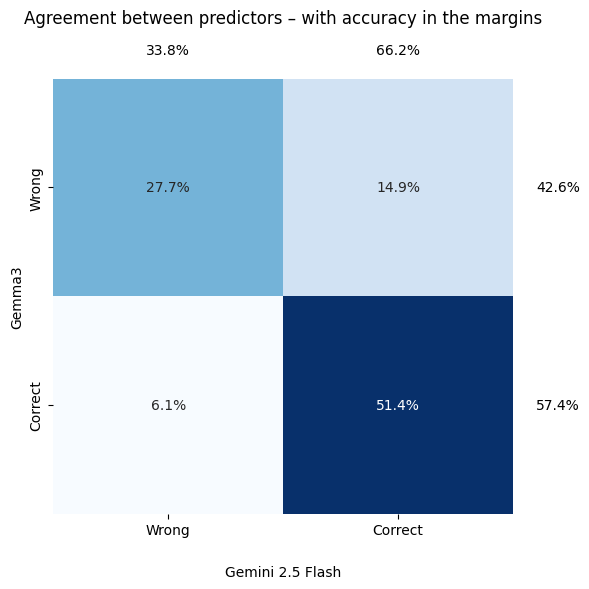

(148, 10)


In [145]:
display_eval = eval_df_all
pred_vqa_correct = (display_eval['text'] == display_eval['pred_text1']).astype(int).values
pred_gg_correct  = (display_eval['text'] == display_eval['pred_text2']).astype(int).values
labels = ['Wrong', 'Correct']

# confusion matrix (normalized over all)
cm = confusion_matrix(pred_vqa_correct, pred_gg_correct, normalize='all')

# compute marginal sums and convert to % of total
row_totals = cm.sum(axis=1)
col_totals = cm.sum(axis=0)
total = cm.sum()
row_pct = row_totals / total
col_pct = col_totals / total

fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='.1%', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            cbar=False, ax=ax)

# annotate row marginals at the right of each row
for i, p in enumerate(row_pct):
    ax.text(len(labels) + 0.1,  i + 0.5, f'{p:.1%}', 
            va='center', ha='left', fontsize=10)

# annotate column marginals just above each column
for j, p in enumerate(col_pct):
    ax.text(j + 0.5, -0.1, f'{p:.1%}', 
            ha='center', va='bottom', fontsize=10)

# move x-axis labels (and xlabel) to the top
ax.set_xlabel('Gemini 2.5 Flash', labelpad=20)
ax.set_ylabel('Gemma3')
ax.set_title('Agreement between predictors – with accuracy in the margins', pad=40)

# make xtick labels horizontal
ax.set_xticklabels(labels, rotation=0)

plt.tight_layout()
plt.show()
print(eval_df_all.shape)


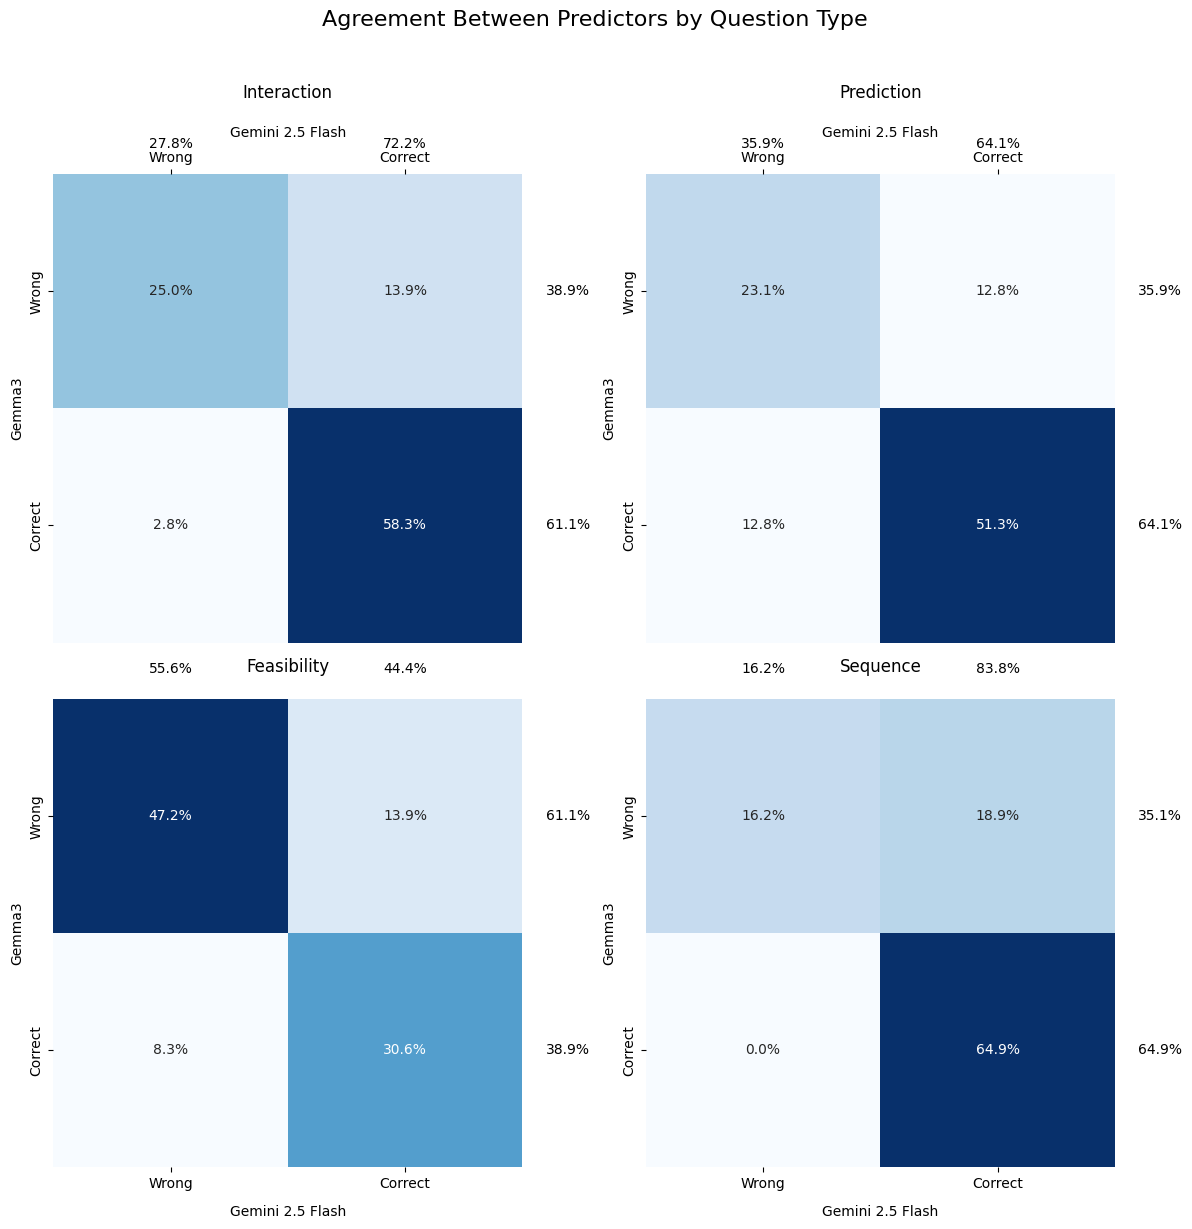

In [146]:
# Create a copy of the DataFrame for visualization
viz_df = eval_df_all.copy()

# Extract question type from the index
viz_df['question_type'] = viz_df.index.str.split('_').str[0]

# Get unique question types
question_types = viz_df['question_type'].unique()

# Set up the plot grid
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
fig.suptitle('Agreement Between Predictors by Question Type', y=1.02, fontsize=16)

# Flatten axes for easy iteration
axes = axes.flatten()

for i, qtype in enumerate(question_types):
    # Filter data for this question type
    subset = viz_df[viz_df['question_type'] == qtype]
    
    # Calculate correctness
    pred_vqa_correct = (subset['text'] == subset['pred_text1']).astype(int).values
    pred_gg_correct = (subset['text'] == subset['pred_text2']).astype(int).values
    
    # Confusion matrix (normalized over all)
    cm = confusion_matrix(pred_vqa_correct, pred_gg_correct, normalize='all')
    
    # Compute marginal sums
    row_totals = cm.sum(axis=1)
    col_totals = cm.sum(axis=0)
    total = cm.sum()
    row_pct = row_totals / total
    col_pct = col_totals / total
    
    # Create heatmap
    sns.heatmap(cm, annot=True, fmt='.1%', cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                cbar=False, ax=axes[i])
    
    # Annotate row marginals
    for j, p in enumerate(row_pct):
        axes[i].text(len(labels) + 0.1, j + 0.5, f'{p:.1%}', 
                    va='center', ha='left', fontsize=10)
    
    # Annotate column marginals
    for k, p in enumerate(col_pct):
        axes[i].text(k + 0.5, -0.1, f'{p:.1%}', 
                    ha='center', va='bottom', fontsize=10)
    
    # Customize subplot
    axes[i].set_title(qtype, pad=20)
    axes[i].set_xlabel('Gemini 2.5 Flash', labelpad=10)
    axes[i].set_ylabel('Gemma3')
    axes[i].set_xticklabels(labels, rotation=0)
    
    # Move x-axis to top for all but bottom row
    if i < 2:  # Top row
        axes[i].xaxis.set_ticks_position('top')
        axes[i].xaxis.set_label_position('top')

plt.tight_layout()
plt.show()


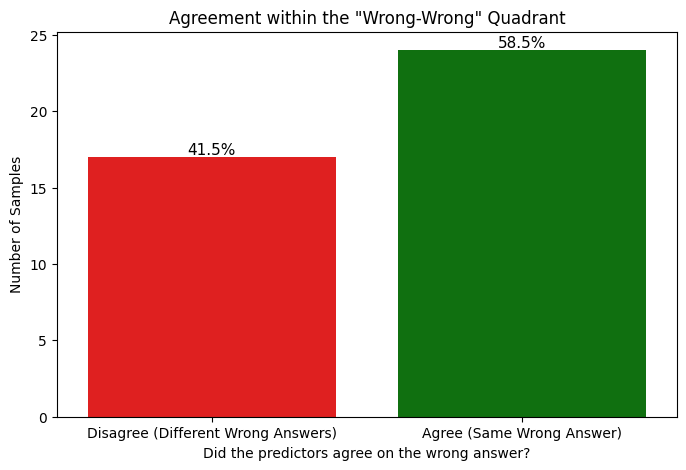

In [147]:
wrong_wrong_df = eval_df_all[
    (eval_df_all['text'] != eval_df_all['pred_text1']) &
    (eval_df_all['text'] != eval_df_all['pred_text2'])
].copy()

wrong_wrong_df['agreement_on_wrong'] = (
    wrong_wrong_df['pred_text1'] == wrong_wrong_df['pred_text2']
)

# Visualize the result
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=wrong_wrong_df,
    x='agreement_on_wrong',
    hue='agreement_on_wrong',
    palette=['Red', 'Green'],
    legend=False
)

plt.title('Agreement within the "Wrong-Wrong" Quadrant')
plt.ylabel('Number of Samples')
plt.xlabel('Did the predictors agree on the wrong answer?')
ax.set_xticks([0, 1]) 
ax.set_xticklabels(['Disagree (Different Wrong Answers)', 'Agree (Same Wrong Answer)'])

# Add percentage annotations
total = len(wrong_wrong_df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=11)

plt.show()


/tmp/ipykernel_1373397/1012052540.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


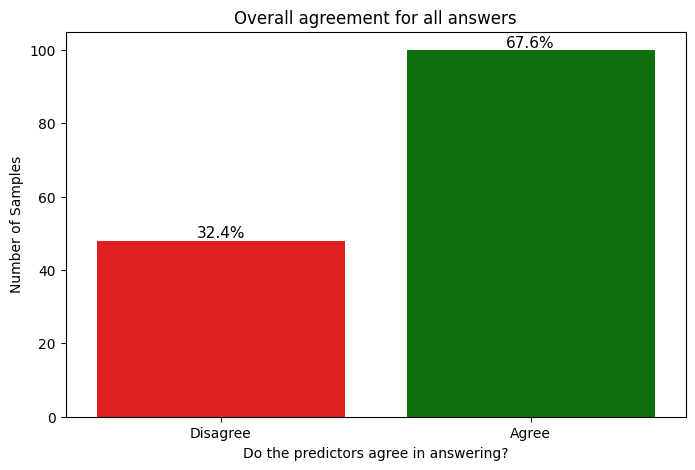

In [148]:
agreement_df = pd.DataFrame((eval_df_all['pred_text1'] == eval_df_all['pred_text2']), columns=['agreement'])

# Visualize the result
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=agreement_df,
    x='agreement',
    palette=['Red', 'Green']
)

plt.title('Overall agreement for all answers')
plt.ylabel('Number of Samples')
plt.xlabel('Do the predictors agree in answering?')
ax.set_xticks([0, 1]) 
ax.set_xticklabels(['Disagree', 'Agree'])

# Add percentage annotations
total = len(agreement_df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=11)

plt.show()


/tmp/ipykernel_1373397/1369200679.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
/tmp/ipykernel_1373397/1369200679.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
/tmp/ipykernel_1373397/1369200679.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(
/tmp/ipykernel_1373397/1369200679.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


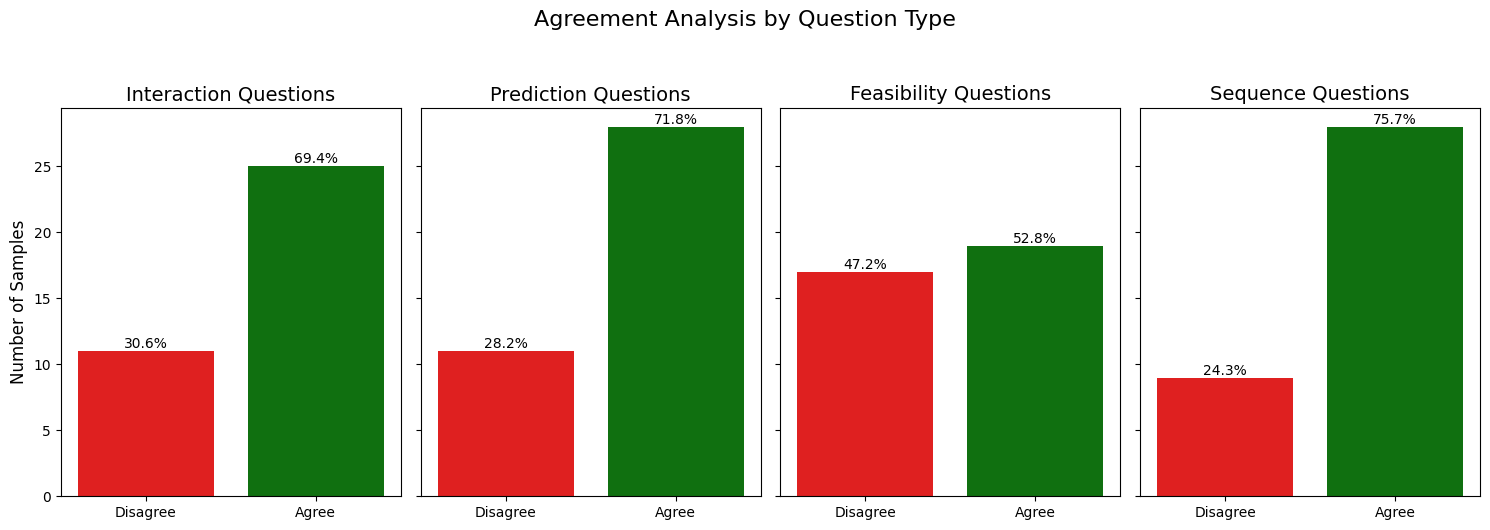

In [149]:
# Create a copy of the DataFrame for visualization
viz_df = eval_df_all.copy()

# Extract question type from the index
viz_df['question_type'] = viz_df.index.str.split('_').str[0]

# Create agreement column in the copy
viz_df['agreement'] = viz_df['pred_text1'] == viz_df['pred_text2']

# Get unique question types
question_types = viz_df['question_type'].unique()
n_types = len(question_types)

# Create subplots
fig, axes = plt.subplots(1, n_types, figsize=(15, 5), sharey=True)
fig.suptitle('Agreement Analysis by Question Type', fontsize=16, y=1.05)

for i, qtype in enumerate(question_types):
    # Filter data for this question type
    subset = viz_df[viz_df['question_type'] == qtype]
    
    # Create countplot
    ax = sns.countplot(
        data=subset,
        x='agreement',
        palette=['Red', 'Green'],
        ax=axes[i]
    )
    
    # Set title and labels
    ax.set_title(f'{qtype} Questions', fontsize=14)
    ax.set_xlabel('')
    if i == 0:
        ax.set_ylabel('Number of Samples', fontsize=12)
    
    # Set x-ticks
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Disagree', 'Agree'])
    
    # Add percentage annotations
    total = len(subset)
    for p in ax.patches:
        percentage = f'{100 * p.get_height() / total:.1f}%'
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


## Inspection

In [ ]:
filtered_prev_analyzed = [x for x in prev_analyzed if x in eval_df_gemini.index]
len(filtered_prev_analyzed)


10

In [151]:
rp.print_acc(eval_df_gemini.loc[filtered_prev_analyzed], lambda x: rp.accuracy(x, on_what='text'))


Question type       Total      Accuracy 

Interaction          10         70.00%  
Sequence              0          nan%   
Prediction            0          nan%   
Feasibility           0          nan%   

Average              10         70.00%  


/home/lusha/star_code/src/response_processing.py:292: RuntimeWarning: invalid value encountered in scalar divide
  return hits_text / eval_df.shape[0]


In [152]:
correct_idx = (eval_df_gemini.loc[filtered_prev_analyzed, 'text'] == eval_df_gemini.loc[filtered_prev_analyzed, 'pred_text'])
correct_idx =  correct_idx[correct_idx].index
correct_idx


Index(['Interaction_T1_8913', 'Interaction_T1_4115', 'Interaction_T1_2516',
       'Interaction_T1_8967', 'Interaction_T1_111', 'Interaction_T1_8274',
       'Interaction_T1_4221'],
      dtype='object')

In [153]:
idx = correct_idx[0]


In [155]:
qa_viz.compact_print_qa(idx, gt_df.rename(columns={'text': 'answer'}), [gemini_pred_gg_df])



┌─ Sample: Interaction_T1_8913 ─────────────────────────────────────────────────────────────
│
│ Question:
│    Which object was taken by the person?
│ Alternatives:
│    0. The paper/notebook.
│    1. The laptop.
│    2. The bag.
│    3. The cup/glass/bottle.
│
│ Ground Truth:
│    The paper/notebook.
│
|
│ Model Predictions - Prediction 1:
│    Prediction:  The paper/notebook. [CORRECT]
│    Reasoning:
│        
│        1. **Question Interpretation:** The question asks to identify which object the person (man) took based on the provided Spatio-Temporal Scene Graph.
│        
│        2. **STSG Analysis:**
│            *   **Frame 0:** The man is moving towards the chair. A smartphone is on the bed and a laptop is on the desk. No object is being taken yet.
│            *   **Frame 1:** The man is sitting on the chair. His left hand is holding a "thin_object" which is not explicitly identified as being taken *from* somewhere. The laptop is on the desk, and the smartphone is on the be

In [156]:
if SHOW_VIDEO:
    videoviz.Vis_Video(
        {"question_id": idx, **gt_df.loc[idx].to_dict()},
        RAW_VIDEO_DIR,
        SAVE_VIDEO_DIR)


In [157]:
print(pred_sgg_df.loc[idx]['chat_history'][0]['content'])


NameError: name 'pred_sgg_df' is not defined